# Task 3 - RNN: Sequence Classification

In [30]:
import sys
!{sys.executable} -m pip install torch

In [31]:
import torch
print(torch.__version__)

2.12.0


In [32]:
# Import and load library of the task
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

In [ ]:
# load sliding window dataset from task 

X_train_w = np.load("../data/3_processed/X_train_w.npy")
y_train_w = np.load("../data/3_processed/y_train_w.npy")

X_test_w = np.load("../data/3_processed/X_test_w.npy")
y_test_w = np.load("../data/3_processed/y_test_w.npy")

print("X_train_w shape:", X_train_w.shape)
print("y_train_w shape:", y_train_w.shape)
print("X_test_w shape:", X_test_w.shape)
print("y_test_w shape:", y_test_w.shape)




X_train_w shape: (24027, 10, 8)
y_train_w shape: (24027,)
X_test_w shape: (6009, 10, 8)
y_test_w shape: (6009,)


In [35]:
# ============================================================
# 2. Encode labels if they are still strings
# ============================================================

label_to_id = {"N": 0, "S": 1, "V": 2}
id_to_label = {0: "N",  1: "S", 2: "V"}

if y_train_w.dtype.kind in {"U", "S", "0"}:
    y_train_w = np.array([label_to_id[label] for label in y_train_w])
    y_test_w = np.array([label_to_id[label] for label in y_test_w])

    print("Unique train labels:", np.unique(y_train_w))
    print("Unique test labels:", np.unique(y_test_w))

In [36]:
# ============================================================
# 3. Convert arrays to PyTorch tensors
# ============================================================

X_train_tensor = torch.tensor(X_train_w, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_w, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train_w, dtype = torch.long)
y_test_tensor = torch.tensor(y_test_w, dtype = torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)


torch.Size([24027, 10, 8])
torch.Size([24027])


In [37]:
# ============================================================
# 4. Create PyTorch Dataset and DataLoader
# ============================================================

class ECGSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]
        
train_dataset = ECGSequenceDataset(X_train_tensor, y_train_tensor)
test_dataset = ECGSequenceDataset(X_test_tensor, y_test_tensor)

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [47]:
# ============================================================
# 5. Define Vanilla RNN Classifier
# ============================================================

class RNNClassifier(nn.Module):
    def __init__(
        self,
        input_size=8,
        hidden_size=64,
        num_layers=1,
        num_classes=3
    ):
        super(RNNClassifier, self).__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        rnn_output, hidden = self.rnn(x)

        last_output = rnn_output[:, -1, :]

        output = self.fc(last_output)

        return output

In [48]:
# ============================================================
# 6. Initialize model, loss function, and optimizer
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = RNNClassifier(
    input_size=8,
    hidden_size=64,
    num_layers=1,
    num_classes=3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

Using device: cpu


In [56]:
# ============================================================
# 7. Train RNN model
# ============================================================

train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):

    # -------------------------
    # Training phase
    # -------------------------
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    train_loss = running_train_loss / total_train
    train_accuracy = correct_train / total_train

    # -------------------------
    # Validation / test phase
    # -------------------------
    model.eval()

    running_test_loss = 0.0
    correct_test = 0
    total_test = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_test_loss += loss.item() * X_batch.size(0)

            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()

    test_loss = running_test_loss / total_test
    test_accuracy = correct_test / total_test

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}"
    )

Epoch [1/20] Train Loss: 0.0075, Train Acc: 0.9986 | Test Loss: 0.0164, Test Acc: 0.9953
Epoch [2/20] Train Loss: 0.0071, Train Acc: 0.9985 | Test Loss: 0.0160, Test Acc: 0.9952
Epoch [3/20] Train Loss: 0.0070, Train Acc: 0.9987 | Test Loss: 0.0161, Test Acc: 0.9957
Epoch [4/20] Train Loss: 0.0066, Train Acc: 0.9985 | Test Loss: 0.0152, Test Acc: 0.9965
Epoch [5/20] Train Loss: 0.0065, Train Acc: 0.9985 | Test Loss: 0.0160, Test Acc: 0.9960
Epoch [6/20] Train Loss: 0.0059, Train Acc: 0.9988 | Test Loss: 0.0160, Test Acc: 0.9955
Epoch [7/20] Train Loss: 0.0059, Train Acc: 0.9987 | Test Loss: 0.0164, Test Acc: 0.9958
Epoch [8/20] Train Loss: 0.0048, Train Acc: 0.9992 | Test Loss: 0.0169, Test Acc: 0.9955
Epoch [9/20] Train Loss: 0.0048, Train Acc: 0.9990 | Test Loss: 0.0151, Test Acc: 0.9957
Epoch [10/20] Train Loss: 0.0043, Train Acc: 0.9992 | Test Loss: 0.0155, Test Acc: 0.9953
Epoch [11/20] Train Loss: 0.0047, Train Acc: 0.9990 | Test Loss: 0.0157, Test Acc: 0.9955
Epoch [12/20] Train

The result show that:
- The training accuracy: ~99.94%
- Test accuracy: ~99.57%
- Test loss stay low around 0.015-0.0185
- Train loss 


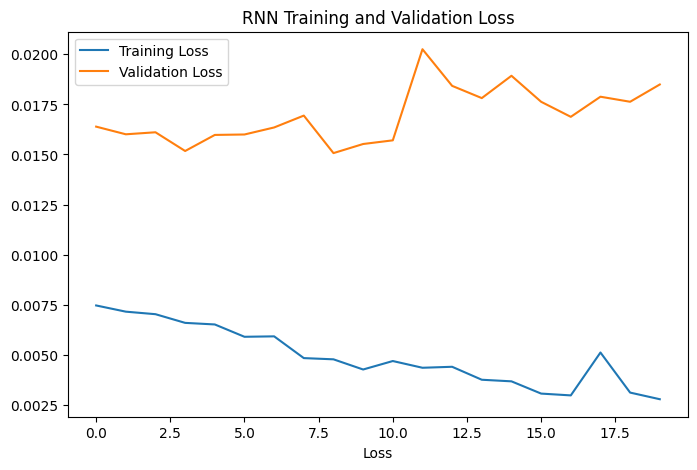

In [57]:
# ============================================================
# 8. Plot training and validation loss
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label = "Training Loss")
plt.plot(test_losses, label = "Validation Loss")
plt.xlabel("Epoch")
plt.xlabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.show()

The training loss decreases consistently throughout the epochs, while the validation loss stabilizes after approximately epoch 10. This suggests that the model successfully learned the underlying temporal patterns in the ECG sequences. Small fluctuations in validation loss are expected due to stochastic optimization and class imbalance.

The widening gap between training and validation loss after later epochs may indicate mild overfitting, although the validation loss remains low overall. The RNN generalizes well to unseen heartbeat sequences, achieving stable performance across the test set.

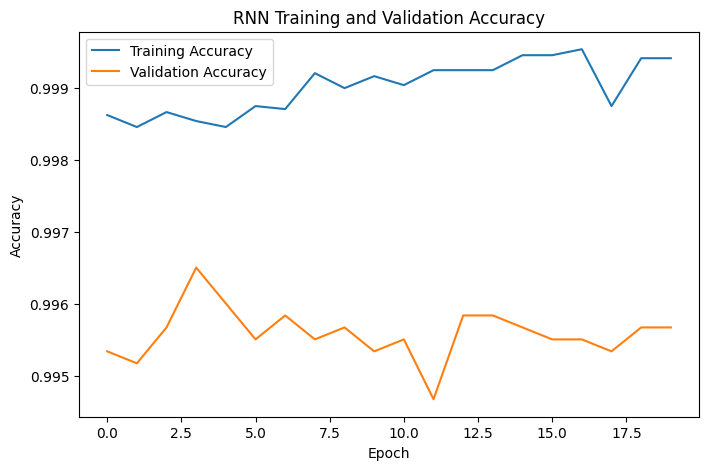

In [59]:
# ============================================================
# 9. Plot training and validation accuracy
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(test_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.show()

The RNN accuracy curves show stable convergence throughout training. Training accuracy gradually increases toward approximately 99.9%, while validation accuracy remains consistently high around 99.5–99.6%.

The small gap between training and validation accuracy indicates that the model generalizes well and does not exhibit severe overfitting. The stability of the validation curve suggests that the engineered ECG features provide strong discriminative information for heartbeat classification.

Although minor fluctuations are visible in the validation accuracy, these are expected due to stochastic optimization and class imbalance in the dataset. Overall, the RNN successfully captures short-term temporal dependencies across the 10-beat sliding windows.

In [60]:
# ============================================================
# 10. Generate predictions on test set
# ============================================================

model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(y_batch.numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

In [61]:
# ============================================================
# 11. Classification report
# ============================================================

target_names = ["N", "S", "V"]

print("RNN Classification Report")
print(classification_report(
    all_true_labels,
    all_predictions,
    target_names=target_names
))

RNN Classification Report
              precision    recall  f1-score   support

           N       1.00      1.00      1.00      5661
           S       0.80      0.88      0.83        40
           V       0.99      0.95      0.97       308

    accuracy                           1.00      6009
   macro avg       0.93      0.94      0.93      6009
weighted avg       1.00      1.00      1.00      6009



- **N class:** almost perfect classification
- **V class:** excellent performance (F1 = 0.97)
- **S class:** weakest class (F1 = 0.83)
- **Macro F1 = 0.93,** which is the most important metric here because of class imbalance

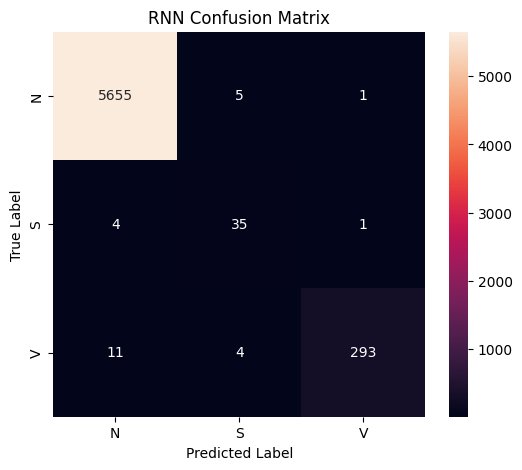

In [62]:
# ============================================================
# 12. Confusion matrix
# ============================================================

cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("RNN Confusion Matrix")
plt.show()

In [63]:
# ============================================================
# 13. Save RNN performance summary
# ============================================================

rnn_accuracy = accuracy_score(all_true_labels, all_predictions)
rnn_macro_f1 = f1_score(all_true_labels, all_predictions, average="macro")
rnn_weighted_f1 = f1_score(all_true_labels, all_predictions, average="weighted")

rnn_results = pd.DataFrame({
    "Model": ["Vanilla RNN"],
    "Accuracy": [rnn_accuracy],
    "Macro F1": [rnn_macro_f1],
    "Weighted F1": [rnn_weighted_f1]
})

rnn_results

,Model,Accuracy,Macro F1,Weighted F1
0,Vanilla RNN,0.995673,0.934429,0.9957


The confusion matrix demonstrates that the RNN achieved excellent heartbeat classification performance across all three classes. Normal beats (N) were classified almost perfectly, with only a few misclassifications. Ventricular ectopic beats (V) also achieved very strong detection performance, which is particularly important in clinical monitoring because missed ventricular arrhythmias may have serious consequences.

The supraventricular ectopic class (S) produced the lowest performance metrics. This is expected because S beats are underrepresented in the dataset and often resemble normal beats morphologically. Most classification errors occurred between the N and S classes, while ventricular beats remained highly separable.

Although the overall accuracy exceeded 99%, macro F1-score provides a more meaningful evaluation due to the strong class imbalance. The macro F1-score of approximately 0.93 indicates that the model generalized well across both majority and minority heartbeat categories.v

In [64]:
# Save results for Task 4 comparison

import os

os.makedirs("../data/4_results", exist_ok=True)

rnn_results.to_csv("../data/4_results/rnn_results.csv", index=False)

torch.save(model.state_dict(), "../data/4_results/rnn_model.pth")